In [57]:
import pandas as pd

df = pd.read_csv("../../data/df_with_cat.csv")
df = df.drop(columns=["Unnamed: 0", "model_response_timestamp", "number"])
display(df.head())

,latitude,longitude,query,org_found,org_name,org_type,org_rating,org_lat,org_lon,name,time,category
0,37.874904,32.492129,Konumumdan en yakın rotayı çıkar,True,Konya Büyükşehir Belediye Stadyumu,Stadyum,4.9,37.946209,32.488097,Konya,2026-02-21 15:09:14,Sports and active recreation
1,41.011219,28.978176,Takı Dünyası Nerdedir?,True,Takı Dünyası,Kozmetik ve parfümeri mağazaları,NaN,41.009805,28.694718,İstanbul,2026-03-01 21:32:04,"Beauty, personal care and wellness"
2,41.011219,28.978176,Şuan bulunduğum konumdan bursa görükle ye gide...,False,NaN,NaN,NaN,NaN,NaN,İstanbul,2026-02-14 10:43:32,Other and unspecified
3,37.062688,37.379510,Milano da gezilecek yerler bana söyler misin?,False,NaN,NaN,NaN,NaN,NaN,Gaziantep,2026-02-22 06:41:22,Other and unspecified
4,37.181190,33.222247,karaman adana arası kaç km ve tır ne yakar,True,Karaman,Locality,NaN,37.181193,33.222241,Karaman,2026-02-23 08:42:57,"Landmarks, addresses and geography"


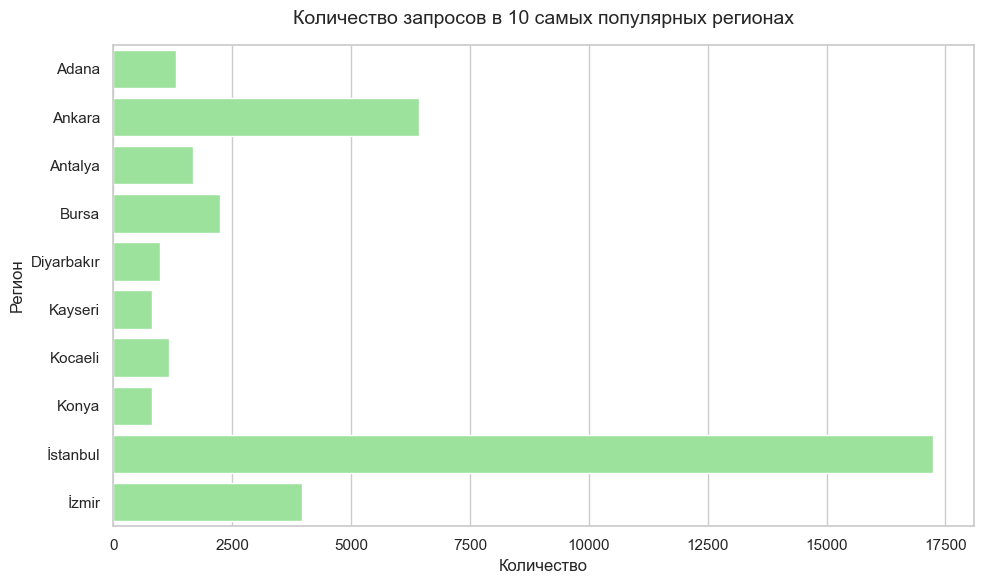

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns

grouped_df = (
    df.groupby("name")["query"].count().reset_index(name="count")
)
grouped_df = grouped_df[grouped_df["count"] >= 750]
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
sns.barplot(
    data=grouped_df,
    x="count",
    y="name",
    color="lightgreen"
)

plt.title("Количество запросов в 10 самых популярных регионах", fontsize=14, pad=15)
plt.xlabel("Количество", fontsize=12)
plt.ylabel("Регион", fontsize=12)

plt.tight_layout()
plt.savefig('regions.png')
plt.show()

In [59]:
grouped_df = (
    df.groupby("name")["query"].count().reset_index(name="count")
)
grouped_df["name"] = grouped_df.apply(
    lambda row: row["name"] if row["count"] >= 15000 else "Other", 
    axis=1
)
grouped_df = (
    grouped_df.groupby("name")["count"].sum().reset_index()
)
grouped_df = grouped_df.sort_values(by="count", ascending=False)
display(grouped_df.head())

,name,count
0,Other,30141
1,İstanbul,17238


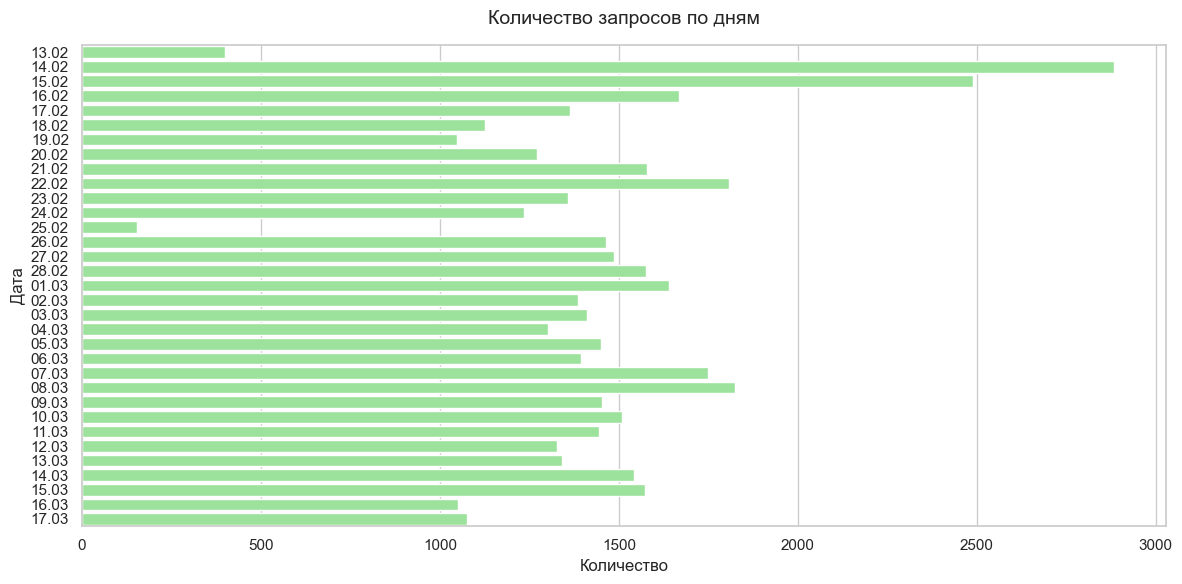

In [77]:
df["time"] = pd.to_datetime(df["time"])

# Выделяем чистую дату для правильной сортировки и красивую строку для графика
df["date"] = df["time"].dt.date
df["day_name"] = df["time"].dt.strftime("%d.%m")

# Группируем по обоим столбцам, чтобы сохранить связь между датой и строкой
grouped_df = (
    df.groupby(["date", "day_name"])["query"].count().reset_index(name="count")
)

# Сортируем по реальной дате (хронологически)
grouped_df = grouped_df.sort_values(by="date")

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Строим график, используя day_name для отображения
sns.barplot(data=grouped_df, x="count", y="day_name", color="lightgreen")

plt.title("Количество запросов по дням", fontsize=14, pad=15)
plt.xlabel("Количество", fontsize=12)
plt.ylabel("Дата", fontsize=12)

plt.tight_layout()
plt.savefig('days.png')
plt.show()

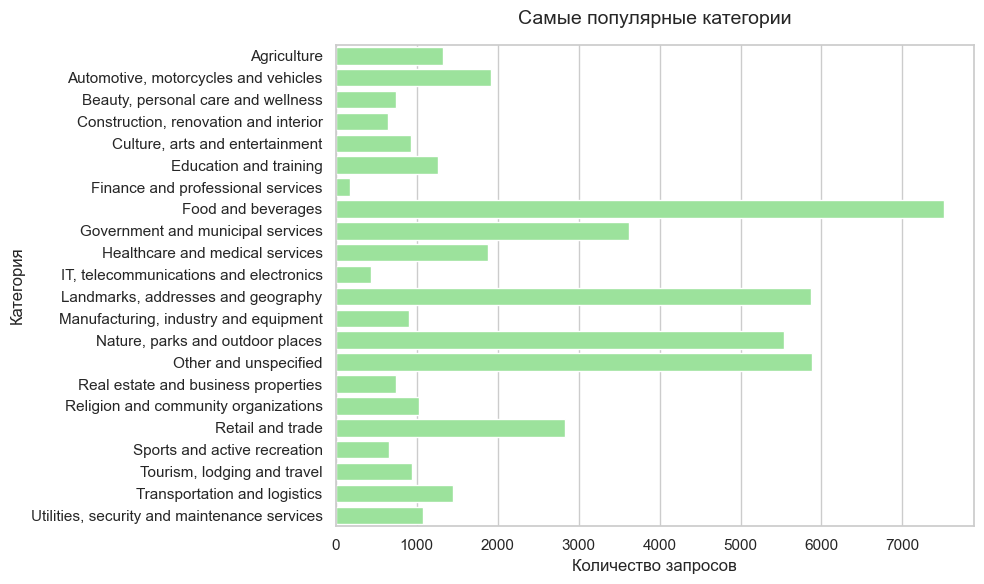

In [78]:
grouped_df = (
    df.groupby("category")["query"].count().reset_index(name="count")
)
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
sns.barplot(
    data=grouped_df,
    x="count",
    y="category",
    color="lightgreen"
)

plt.title("Самые популярные категории", fontsize=14, pad=15)
plt.xlabel("Количество запросов", fontsize=12)
plt.ylabel("Категория", fontsize=12)

plt.tight_layout()
plt.savefig('categories.png')
plt.show()

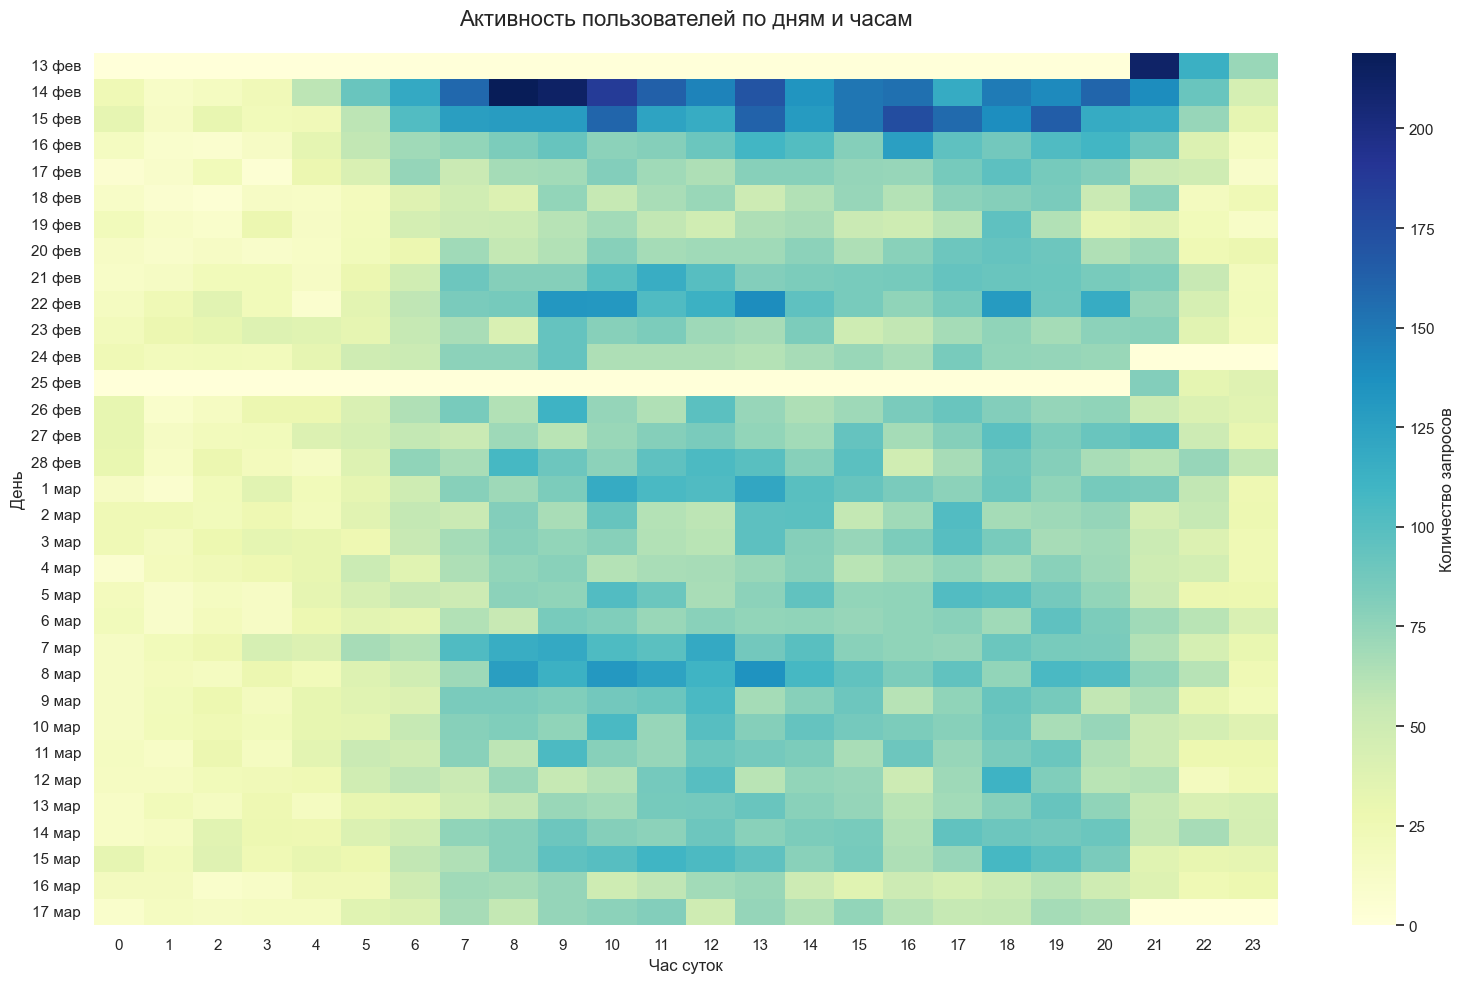

In [65]:
df["time"] = pd.to_datetime(df["time"])

ru_months = {
    1: "янв", 2: "фев", 3: "мар", 4: "апр", 5: "май", 6: "июн",
    7: "июл", 8: "авг", 9: "сен", 10: "окт", 11: "ноя", 12: "дек"
}

df["day_name"] = df["time"].dt.day.astype(str) + " " + df["time"].dt.month.map(ru_months)
df["hour"] = df["time"].dt.hour

pivot_df = df.pivot_table(
    index="day_name", 
    columns="hour", 
    values="query", 
    aggfunc="count", 
    fill_value=0
)

df_sorted_days = df.sort_values("time")["day_name"].unique()
pivot_df = pivot_df.reindex(df_sorted_days)

plt.figure(figsize=(16, 10))
sns.set_theme(style="white")

sns.heatmap(
    pivot_df, 
    cmap="YlGnBu", 
    annot=False, 
    cbar_kws={"label": "Количество запросов"}
)

plt.title("Активность пользователей по дням и часам", fontsize=16, pad=20)
plt.xlabel("Час суток", fontsize=12)
plt.ylabel("День", fontsize=12)

plt.tight_layout()
plt.show()

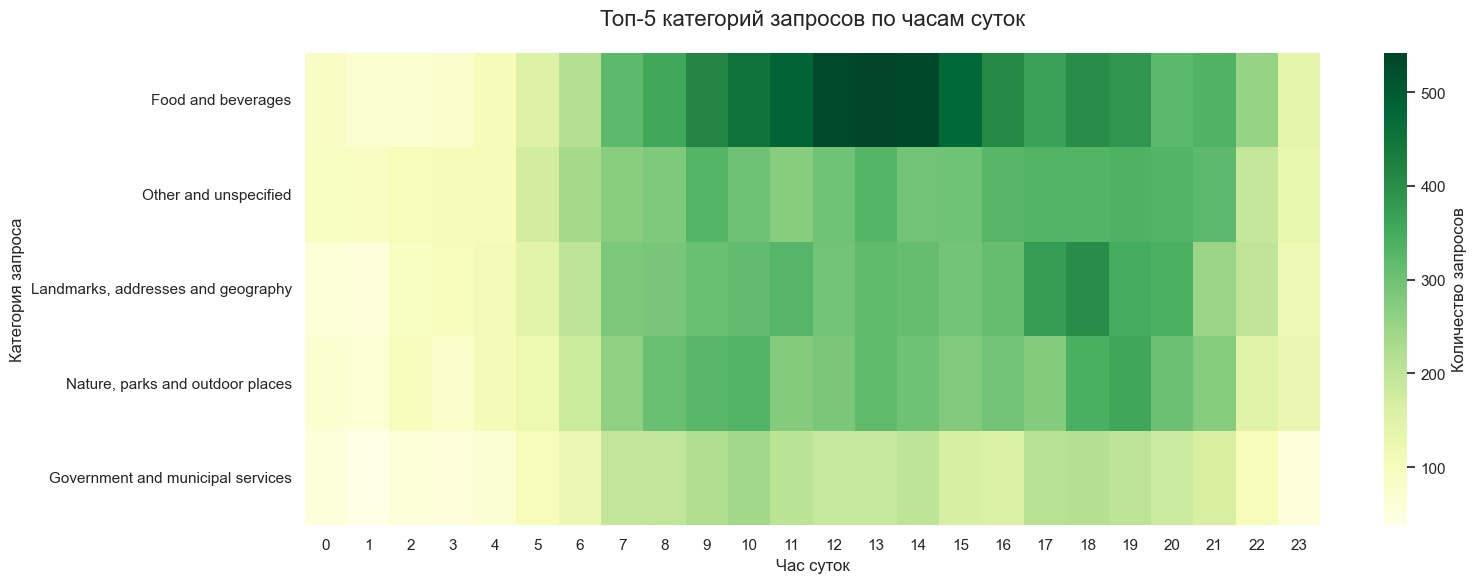

In [81]:
df["time"] = pd.to_datetime(df["time"])
df["hour"] = df["time"].dt.hour

pivot_df = df.pivot_table(
    index="category", 
    columns="hour", 
    values="query", 
    aggfunc="count", 
    fill_value=0
)

top_5_categories = df["category"].value_counts().head(5).index
pivot_df = pivot_df.reindex(top_5_categories)

plt.figure(figsize=(16, 6))
sns.set_theme(style="white")

sns.heatmap(
    pivot_df, 
    cmap="YlGn", 
    annot=False, 
    fmt="d",
    cbar_kws={"label": "Количество запросов"}
)

plt.title("Топ-5 категорий запросов по часам суток", fontsize=16, pad=20)
plt.xlabel("Час суток", fontsize=12)
plt.ylabel("Категория запроса", fontsize=12)

plt.tight_layout()
plt.savefig('heatmap.png')
plt.show()